# Product Growth Analytics Walkthrough

## Activation, 30-Day Adoption, and Later Activity

This notebook is a public, confidentiality-safe analytical replica inspired by real product analytics work on a large-scale merchant platform.

It uses entirely synthetic data and independently written code. The model is intentionally simplified so the metric definitions, calculations, insights, and decision process can be explained clearly and reproduced publicly.

### Measurement framework

- **Eligible:** merchant belongs to the population able to use the platform.
- **Activated:** merchant completes a first successful transaction.
- **Time to activation:** days between eligibility and activation.
- **30-Day Adoption:** at least 10 successful transactions during days 0–30 after activation.
- **Later active:** at least one successful transaction during days 31–60 after activation.
- **Activation cohort:** month of the first successful transaction.

A production implementation would include additional complexity such as eligibility rules, event-quality controls, identity resolution, refunds and reversals, market differences, rollout timing, statistical uncertainty, operational constraints, and financial impact.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

N_MERCHANTS = 10_000
ANALYSIS_DATE = pd.Timestamp("2025-09-30")

## 2. Generate synthetic merchant data

The synthetic population includes three merchant segments, four markets, eligibility dates, activation behavior, early transaction depth, and later activity.

In [2]:
segments = rng.choice(
    ["Small", "Mid-Market", "Enterprise"],
    size=N_MERCHANTS,
    p=[0.60, 0.30, 0.10]
)

markets = rng.choice(
    ["North America", "Europe", "Latin America", "Asia Pacific"],
    size=N_MERCHANTS,
    p=[0.35, 0.30, 0.20, 0.15]
)

eligible_dates = pd.to_datetime(
    rng.choice(
        pd.date_range("2025-01-01", "2025-06-30", freq="D"),
        size=N_MERCHANTS
    )
)

merchant_data = pd.DataFrame({
    "merchant_id": np.arange(1, N_MERCHANTS + 1),
    "segment": segments,
    "market": markets,
    "eligible_date": eligible_dates
})

activation_probability = {
    "Small": 0.61,
    "Mid-Market": 0.73,
    "Enterprise": 0.82
}

merchant_data["activated"] = [
    rng.random() < activation_probability[segment]
    for segment in merchant_data["segment"]
]

activation_delay_mean = {
    "Small": 18,
    "Mid-Market": 12,
    "Enterprise": 8
}

days_to_activation = []

for activated, segment in zip(
    merchant_data["activated"],
    merchant_data["segment"]
):
    if activated:
        delay = int(
            max(
                0,
                rng.gamma(
                    shape=2.0,
                    scale=activation_delay_mean[segment] / 2
                )
            )
        )
        days_to_activation.append(delay)
    else:
        days_to_activation.append(np.nan)

merchant_data["days_to_activation"] = days_to_activation
merchant_data["activation_date"] = pd.NaT

activated_mask = merchant_data["activated"]

merchant_data.loc[activated_mask, "activation_date"] = (
    merchant_data.loc[activated_mask, "eligible_date"]
    + pd.to_timedelta(
        merchant_data.loc[activated_mask, "days_to_activation"],
        unit="D"
    )
)

merchant_data["activation_month"] = (
    merchant_data["activation_date"]
    .dt.to_period("M")
    .astype("string")
)

transactions_0_30_mean = {
    "Small": 8,
    "Mid-Market": 13,
    "Enterprise": 20
}

merchant_data["successful_transactions_days_0_30"] = [
    max(1, int(rng.poisson(transactions_0_30_mean[segment])))
    if activated else 0
    for activated, segment in zip(
        merchant_data["activated"],
        merchant_data["segment"]
    )
]

merchant_data["adopted_30d"] = (
    merchant_data["successful_transactions_days_0_30"] >= 10
)

later_activity_probability = {
    "Small": {False: 0.42, True: 0.72},
    "Mid-Market": {False: 0.52, True: 0.81},
    "Enterprise": {False: 0.62, True: 0.88}
}

later_transaction_mean = {
    "Small": 5,
    "Mid-Market": 9,
    "Enterprise": 15
}

transactions_31_60 = []

for activated, adopted_30d, segment in zip(
    merchant_data["activated"],
    merchant_data["adopted_30d"],
    merchant_data["segment"]
):
    if not activated:
        transactions_31_60.append(0)
        continue

    is_later_active = (
        rng.random()
        < later_activity_probability[segment][adopted_30d]
    )

    if not is_later_active:
        transactions_31_60.append(0)
        continue

    expected_transactions = later_transaction_mean[segment]

    if adopted_30d:
        expected_transactions *= 1.35

    transactions_31_60.append(
        max(1, int(rng.poisson(expected_transactions)))
    )

merchant_data["successful_transactions_days_31_60"] = (
    transactions_31_60
)

merchant_data["later_active"] = (
    merchant_data["successful_transactions_days_31_60"] >= 1
)

merchant_data["mature_30d"] = (
    merchant_data["activated"]
    & (
        merchant_data["activation_date"]
        <= ANALYSIS_DATE - pd.Timedelta(days=30)
    )
)

merchant_data["mature_60d"] = (
    merchant_data["activated"]
    & (
        merchant_data["activation_date"]
        <= ANALYSIS_DATE - pd.Timedelta(days=60)
    )
)

merchant_data.head()

,merchant_id,segment,market,eligible_date,activated,days_to_activation,activation_date,activation_month,successful_transactions_days_0_30,adopted_30d,successful_transactions_days_31_60,later_active,mature_30d,mature_60d
0,1,Mid-Market,Latin America,2025-06-12,False,NaN,NaT,<NA>,0,False,0,False,False,False
1,2,Small,Latin America,2025-05-15,False,NaN,NaT,<NA>,0,False,0,False,False,False
2,3,Mid-Market,North America,2025-02-07,False,NaN,NaT,<NA>,0,False,0,False,False,False
3,4,Mid-Market,North America,2025-06-30,True,10.00,2025-07-10,2025-07,11,True,10,True,True,True
4,5,Small,North America,2025-06-29,True,6.00,2025-07-05,2025-07,9,False,0,False,True,True


## 3. Data-quality validation

In [3]:
validation_checks = pd.DataFrame({
    "Validation check": [
        "Activated merchant without activation date",
        "Non-activated merchant with activation date",
        "30-Day adopter without activation",
        "Later-active merchant without activation",
        "Later-active merchant with zero transactions in days 31–60",
        "Duplicate merchant ID",
        "Negative activation delay",
        "Activation date before eligibility date"
    ],
    "Invalid records": [
        (
            merchant_data["activated"]
            & merchant_data["activation_date"].isna()
        ).sum(),
        (
            ~merchant_data["activated"]
            & merchant_data["activation_date"].notna()
        ).sum(),
        (
            merchant_data["adopted_30d"]
            & ~merchant_data["activated"]
        ).sum(),
        (
            merchant_data["later_active"]
            & ~merchant_data["activated"]
        ).sum(),
        (
            merchant_data["later_active"]
            & (
                merchant_data[
                    "successful_transactions_days_31_60"
                ] == 0
            )
        ).sum(),
        merchant_data["merchant_id"].duplicated().sum(),
        (merchant_data["days_to_activation"] < 0).sum(),
        (
            merchant_data["activation_date"]
            < merchant_data["eligible_date"]
        ).sum()
    ]
})

validation_checks

,Validation check,Invalid records
0,Activated merchant without activation date,0
1,Non-activated merchant with activation date,0
2,30-Day adopter without activation,0
3,Later-active merchant without activation,0
4,Later-active merchant with zero transactions in days 31–60,0
5,Duplicate merchant ID,0
6,Negative activation delay,0
7,Activation date before eligibility date,0


## 4. Executive summary

In [4]:
eligible_count = len(merchant_data)
activated_count = int(merchant_data["activated"].sum())
mature_30d_count = int(merchant_data["mature_30d"].sum())
mature_60d_count = int(merchant_data["mature_60d"].sum())

adopted_30d_count = int(
    merchant_data.loc[
        merchant_data["mature_30d"],
        "adopted_30d"
    ].sum()
)

later_active_count = int(
    merchant_data.loc[
        merchant_data["mature_60d"],
        "later_active"
    ].sum()
)

activation_rate = activated_count / eligible_count
adoption_30d_rate = adopted_30d_count / mature_30d_count
later_activity_rate = later_active_count / mature_60d_count

median_days_to_activation = (
    merchant_data.loc[
        merchant_data["activated"],
        "days_to_activation"
    ].median()
)

summary = pd.DataFrame({
    "Metric": [
        "Eligible merchants",
        "Activated merchants",
        "Activation rate",
        "Median days to activation",
        "Mature 30-day merchants",
        "30-Day Adoption rate",
        "Mature 60-day merchants",
        "Later-activity rate"
    ],
    "Value": [
        f"{eligible_count:,}",
        f"{activated_count:,}",
        f"{activation_rate:.1%}",
        f"{median_days_to_activation:.0f}",
        f"{mature_30d_count:,}",
        f"{adoption_30d_rate:.1%}",
        f"{mature_60d_count:,}",
        f"{later_activity_rate:.1%}"
    ]
})

summary

,Metric,Value
0,Eligible merchants,"10,000"
1,Activated merchants,"6,673"
2,Activation rate,66.7%
3,Median days to activation,11
4,Mature 30-day merchants,"6,673"
5,30-Day Adoption rate,55.8%
6,Mature 60-day merchants,"6,653"
7,Later-activity rate,63.6%


## 5. Activation analysis

In [5]:
segment_summary = (
    merchant_data
    .groupby("segment", observed=True)
    .agg(
        eligible=("merchant_id", "count"),
        activated=("activated", "sum"),
        mature_30d=("mature_30d", "sum"),
        mature_60d=("mature_60d", "sum"),
        median_days_to_activation=("days_to_activation", "median")
    )
    .reset_index()
)

segment_adoption = (
    merchant_data.loc[merchant_data["mature_30d"]]
    .groupby("segment", observed=True)["adopted_30d"]
    .sum()
)

segment_later_activity = (
    merchant_data.loc[merchant_data["mature_60d"]]
    .groupby("segment", observed=True)["later_active"]
    .sum()
)

segment_summary["adopted_30d"] = (
    segment_summary["segment"]
    .map(segment_adoption)
    .fillna(0)
    .astype(int)
)

segment_summary["later_active"] = (
    segment_summary["segment"]
    .map(segment_later_activity)
    .fillna(0)
    .astype(int)
)

segment_summary["activation_rate"] = (
    segment_summary["activated"] / segment_summary["eligible"]
)

segment_summary["adoption_30d_rate"] = (
    segment_summary["adopted_30d"] / segment_summary["mature_30d"]
)

segment_summary["later_activity_rate"] = (
    segment_summary["later_active"] / segment_summary["mature_60d"]
)

segment_summary

,segment,eligible,activated,mature_30d,mature_60d,median_days_to_activation,adopted_30d,later_active,activation_rate,adoption_30d_rate,later_activity_rate
0,Enterprise,985,805,805,805,6.00,803,699,0.82,1.00,0.87
1,Mid-Market,2967,2175,2175,2174,10.00,1837,1663,0.73,0.84,0.76
2,Small,6048,3693,3693,3674,14.00,1083,1867,0.61,0.29,0.51


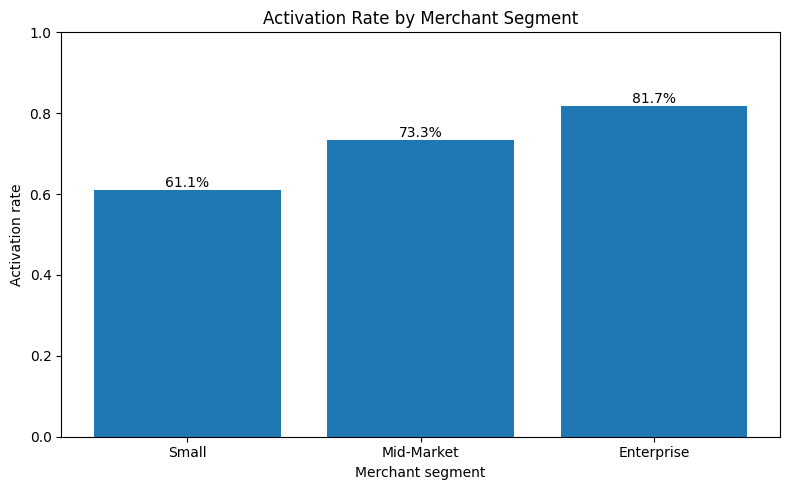

In [6]:
activation_order = segment_summary.sort_values("activation_rate")

plt.figure(figsize=(8, 5))
bars = plt.bar(
    activation_order["segment"],
    activation_order["activation_rate"]
)
plt.title("Activation Rate by Merchant Segment")
plt.xlabel("Merchant segment")
plt.ylabel("Activation rate")
plt.ylim(0, 1)

for bar, rate in zip(
    bars,
    activation_order["activation_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 6. Time to activation

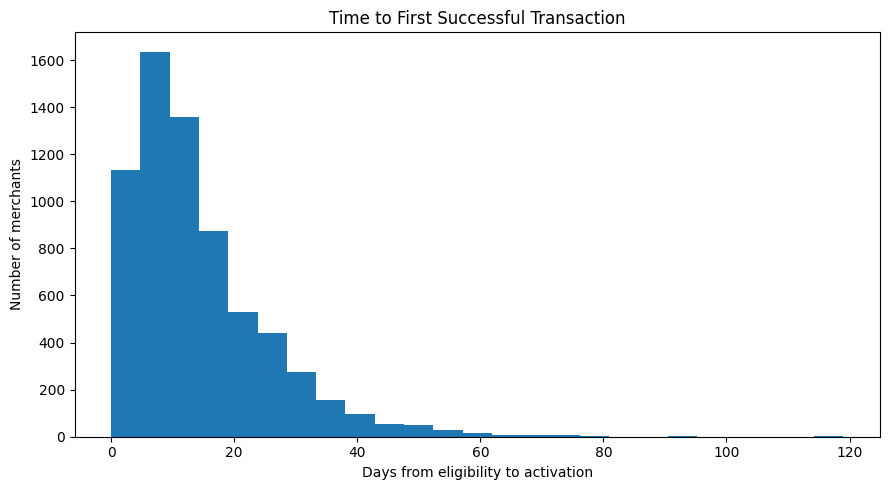

In [7]:
activated_merchants = merchant_data.loc[
    merchant_data["activated"]
].copy()

plt.figure(figsize=(9, 5))
plt.hist(
    activated_merchants["days_to_activation"],
    bins=25
)
plt.title("Time to First Successful Transaction")
plt.xlabel("Days from eligibility to activation")
plt.ylabel("Number of merchants")
plt.tight_layout()
plt.show()

## 7. 30-Day Adoption

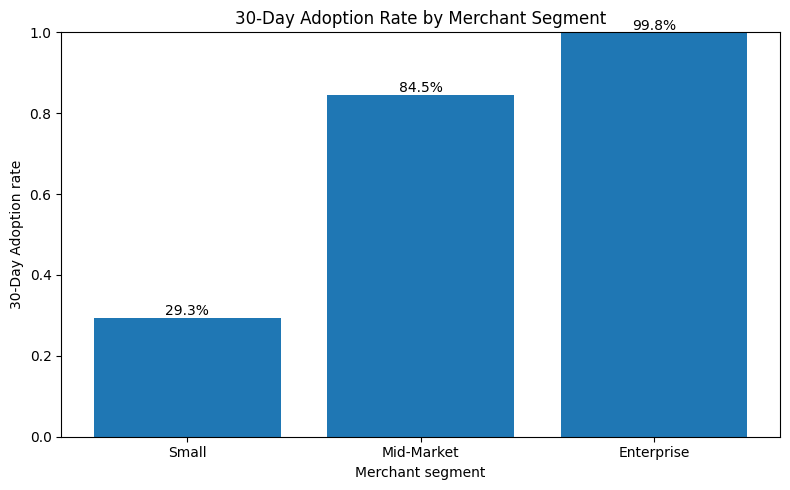

In [8]:
adoption_order = segment_summary.sort_values(
    "adoption_30d_rate"
)

plt.figure(figsize=(8, 5))
bars = plt.bar(
    adoption_order["segment"],
    adoption_order["adoption_30d_rate"]
)
plt.title("30-Day Adoption Rate by Merchant Segment")
plt.xlabel("Merchant segment")
plt.ylabel("30-Day Adoption rate")
plt.ylim(0, 1)

for bar, rate in zip(
    bars,
    adoption_order["adoption_30d_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 8. Activation-cohort analysis

In [9]:
cohort_summary = (
    merchant_data.loc[merchant_data["mature_30d"]]
    .groupby("activation_month", observed=True)
    .agg(
        activated_merchants=("merchant_id", "count"),
        adopted_30d=("adopted_30d", "sum"),
        median_days_to_activation=("days_to_activation", "median")
    )
    .reset_index()
    .sort_values("activation_month")
)

cohort_summary["adoption_30d_rate"] = (
    cohort_summary["adopted_30d"]
    / cohort_summary["activated_merchants"]
)

cohort_summary

,activation_month,activated_merchants,adopted_30d,median_days_to_activation,adoption_30d_rate
0,2025-01,642,395,8.00,0.62
1,2025-02,1031,576,11.00,0.56
2,2025-03,1122,627,12.00,0.56
3,2025-04,1105,602,12.00,0.54
4,2025-05,1188,672,11.00,0.57
5,2025-06,1062,606,11.00,0.57
6,2025-07,499,240,19.00,0.48
7,2025-08,24,5,43.50,0.21


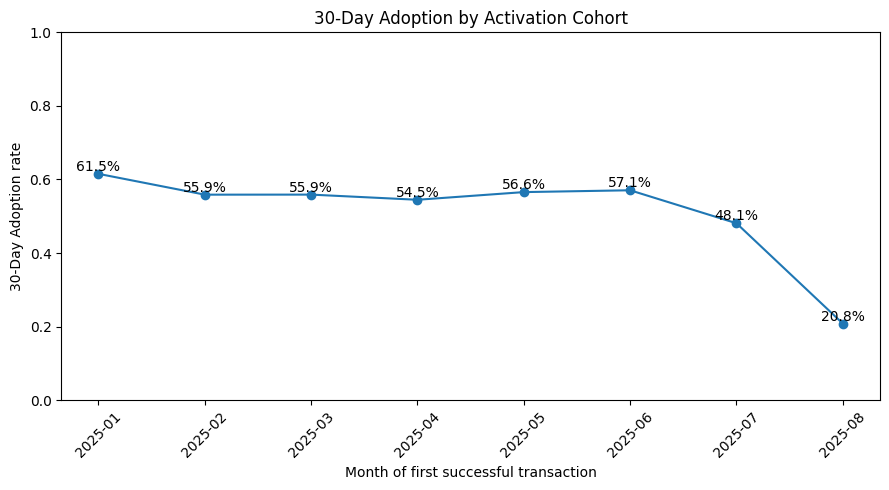

In [10]:
plt.figure(figsize=(9, 5))
plt.plot(
    cohort_summary["activation_month"],
    cohort_summary["adoption_30d_rate"],
    marker="o"
)
plt.title("30-Day Adoption by Activation Cohort")
plt.xlabel("Month of first successful transaction")
plt.ylabel("30-Day Adoption rate")
plt.ylim(0, 1)
plt.xticks(rotation=45)

for month, rate in zip(
    cohort_summary["activation_month"],
    cohort_summary["adoption_30d_rate"]
):
    plt.text(
        month,
        rate,
        f"{rate:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 9. Later activity during days 31–60

In [11]:
later_activity_by_adoption = (
    merchant_data.loc[merchant_data["mature_60d"]]
    .groupby("adopted_30d", observed=True)
    .agg(
        merchants=("merchant_id", "count"),
        later_active_merchants=("later_active", "sum")
    )
    .reset_index()
)

later_activity_by_adoption["later_activity_rate"] = (
    later_activity_by_adoption["later_active_merchants"]
    / later_activity_by_adoption["merchants"]
)

later_activity_by_adoption["early_adoption_status"] = (
    later_activity_by_adoption["adopted_30d"]
    .map({
        False: "Did not reach 30-Day threshold",
        True: "Reached 30-Day threshold"
    })
)

later_activity_by_adoption

,adopted_30d,merchants,later_active_merchants,later_activity_rate,early_adoption_status
0,False,2933,1291,0.44,Did not reach 30-Day threshold
1,True,3720,2938,0.79,Reached 30-Day threshold


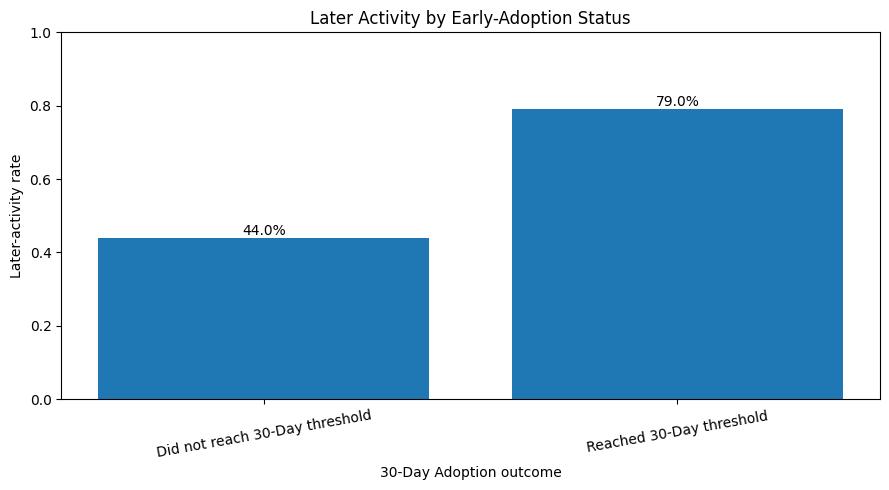

In [12]:
plt.figure(figsize=(9, 5))
bars = plt.bar(
    later_activity_by_adoption["early_adoption_status"],
    later_activity_by_adoption["later_activity_rate"]
)
plt.title("Later Activity by Early-Adoption Status")
plt.xlabel("30-Day Adoption outcome")
plt.ylabel("Later-activity rate")
plt.ylim(0, 1)

for bar, rate in zip(
    bars,
    later_activity_by_adoption["later_activity_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1%}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

### Interpretation

Merchants reaching the 30-Day Adoption threshold are more likely, in this synthetic replica, to complete at least one transaction during days 31–60.

This is descriptive, not causal. The synthetic generator intentionally includes this relationship to demonstrate the method. In production, the analysis would need to account for merchant size, transaction demand, readiness, integration quality, market, and product fit.

## 10. Opportunity sizing

In [13]:
best_activation_rate = segment_summary["activation_rate"].max()

activation_opportunity = segment_summary[
    ["segment", "eligible", "activation_rate"]
].copy()

activation_opportunity["activation_gap"] = (
    best_activation_rate
    - activation_opportunity["activation_rate"]
)

activation_opportunity[
    "incremental_activations_if_gap_closed"
] = (
    activation_opportunity["eligible"]
    * activation_opportunity["activation_gap"]
).round().astype(int)

activation_opportunity.sort_values(
    "incremental_activations_if_gap_closed",
    ascending=False
)

,segment,eligible,activation_rate,activation_gap,incremental_activations_if_gap_closed
2,Small,6048,0.61,0.21,1250
1,Mid-Market,2967,0.73,0.08,250
0,Enterprise,985,0.82,0.00,0


In [14]:
best_adoption_rate = segment_summary["adoption_30d_rate"].max()

adoption_opportunity = segment_summary[
    ["segment", "mature_30d", "adoption_30d_rate"]
].copy()

adoption_opportunity["adoption_gap"] = (
    best_adoption_rate
    - adoption_opportunity["adoption_30d_rate"]
)

adoption_opportunity[
    "incremental_adopters_if_gap_closed"
] = (
    adoption_opportunity["mature_30d"]
    * adoption_opportunity["adoption_gap"]
).round().astype(int)

adoption_opportunity.sort_values(
    "incremental_adopters_if_gap_closed",
    ascending=False
)

,segment,mature_30d,adoption_30d_rate,adoption_gap,incremental_adopters_if_gap_closed
2,Small,3693,0.29,0.70,2601
1,Mid-Market,2175,0.84,0.15,333
0,Enterprise,805,1.00,0.00,0


## 11. Decision framework

A product opportunity should not be prioritized from a rate alone. The decision should consider:

- affected merchant population;
- gap to a relevant benchmark;
- time to activation;
- expected business value;
- addressability;
- implementation effort;
- market and operational constraints;
- measurement feasibility.

## 12. Limitations

This notebook is intentionally simplified. A production analysis would require:

- precise eligibility and exclusion rules;
- merchant identity resolution;
- failed, reversed, and refunded transaction handling;
- exact day-window boundary conventions;
- exclusion of immature cohorts;
- confidence intervals and statistical testing;
- adjustment for merchant mix, rollout timing, and seasonality;
- incremental-impact measurement;
- financial value and implementation-cost estimates;
- privacy, legal, and regulatory review.

## What this notebook demonstrates

- defining activation through an observable value-generating event;
- analyzing activation rate and activation speed separately;
- distinguishing first use from meaningful transaction depth;
- using fixed windows for cohort comparability;
- defining later activity through a concrete event;
- distinguishing association from causality;
- validating analytical data;
- sizing opportunities before recommending action.